In [7]:
#Generated TH2F files live here:

## This dude has 50 events:
simulated_path = "/exp/dune/data/users/mking/ICEBERG_Noise_Ar_39/iceberg_noise/AR_39_sim/10_02_2024/Waveforms_Sim.root"

## This dude has 1000 events:
#Check these ones:
simulated_path = "/exp/dune/data/users/mking/ICEBERG_Noise_Ar_39/iceberg_noise/AR_39_sim/01_24_2025/Waveforms_Sim.root"

## 1000 events, doped with extra Ar39
simulated_path = "/exp/dune/data/users/mking/ICEBERG_Noise_Ar_39/iceberg_noise/AR_39_sim/03_03_2025/Waveforms_Sim.root"


In [2]:
!pip install uproot
!pip install numpy
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [8]:
## Let's start by opening up the data, picking an event with ar-39, and plotting some waveforms with the ar-39 signal overlayed with Ar-39 plus noise
import uproot
import numpy as np
import matplotlib.pyplot as plt
from Analyzer import Analyzer as Analyzer
import gc

In [4]:
## Data structure:
## (Nevents,channel,timetick) e.g. (1000,1280,2128) arrays.
## Break up into waveforms of length 200. -> (10000, 1280,200)
## Save into 10 npz files of (10000, 1280,200)
## Recall that FEMB 8 is redundant with FEMB 1 -- eliminate channels from FEMB 8

#Fill in these zero channels (FEMB 8) with FEMB 1, arbitrarily
#AverageFFTNoCosmics_mV_Filled[280:320] = AverageFFTNoCosmics_mV[160:200] U
#AverageFFTNoCosmics_mV_Filled[680:720] = AverageFFTNoCosmics_mV[400:440] V
#AverageFFTNoCosmics_mV_Filled[1136:1184] = AverageFFTNoCosmics_mV[800:848] Z

In [5]:
## Only bother saving wires with any signal in them. Only save slice of 200 wires with signal in them.
## Save some of the non-signal noise for training the ROI finder.
## Put appropriate sig/daq pairs into buckets of (n_samples,channel,200)
## n_samples is dynamic, so array is only rectangular in the last 2 indices.

In [9]:
infile = uproot.open(simulated_path)
#print(infile.keys())

In [10]:
## The below are to test one event ##

In [12]:
Noise_key = infile.keys()[0]
Ar39_key = infile.keys()[1]

In [13]:
Noise, xedges, yedges = infile[Noise_key].to_numpy()
Ar39, xedges, yedges = infile[Ar39_key].to_numpy()

xcenters = Analyzer.EdgesToCenters(xedges)
timeticks = yedges[:-1]

In [14]:
print(Noise.shape)
print(Ar39.shape)
print(Noise.dtype)
print(Ar39.dtype)
print(Noise.nbytes/(1024**2)) #noise in 
print(Ar39.nbytes/(1024**2)) #noise in MB
print(2128*1280*4/(1024**2))


(1280, 2128)
(1280, 2128)
float32
float32
10.390625
10.390625
10.390625


(1280,)
(1280,)
[-0.00422932  0.          0.         ...  0.          0.
  0.        ]


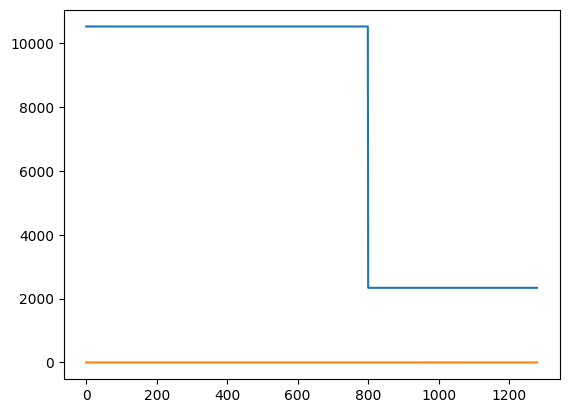

In [15]:
## Baseline subtract channel-by-channel
AvgNoise = np.mean(Noise,axis = 1)
print(AvgNoise.shape)
plt.plot(AvgNoise)
Noise_baseline_sbtr = Noise - AvgNoise[:,np.newaxis]

AvgAr39 = np.mean(Ar39,axis = 1)
print(AvgAr39.shape)
plt.plot(AvgAr39)
Ar39_baseline_sbtr = Ar39 - AvgAr39[:,np.newaxis]
print(AvgAr39)

In [16]:
## True if any element of the array is nonzero
print(np.any(Ar39))

True


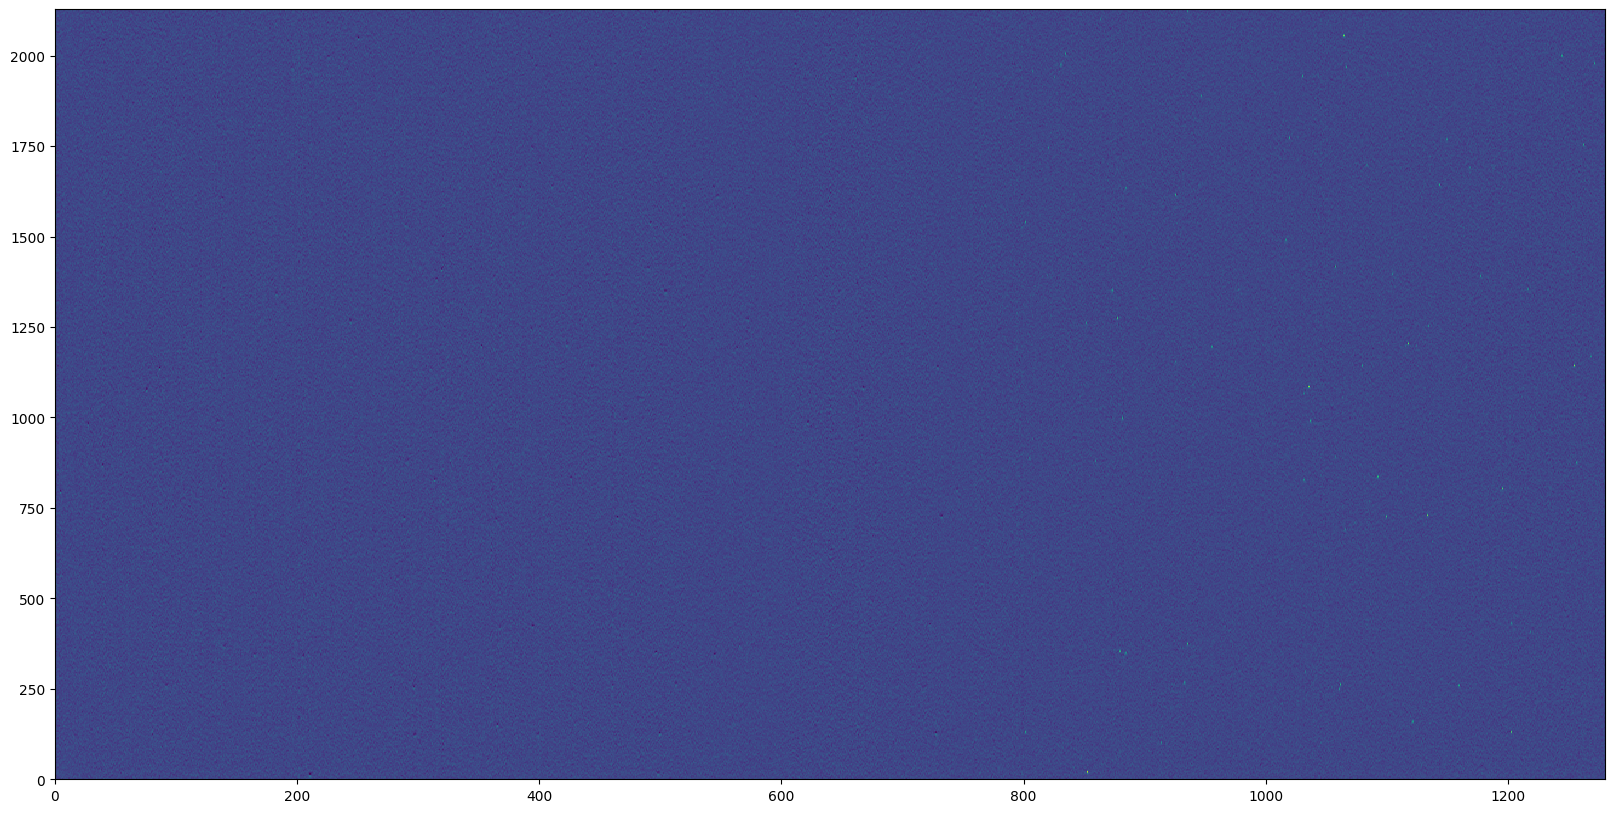

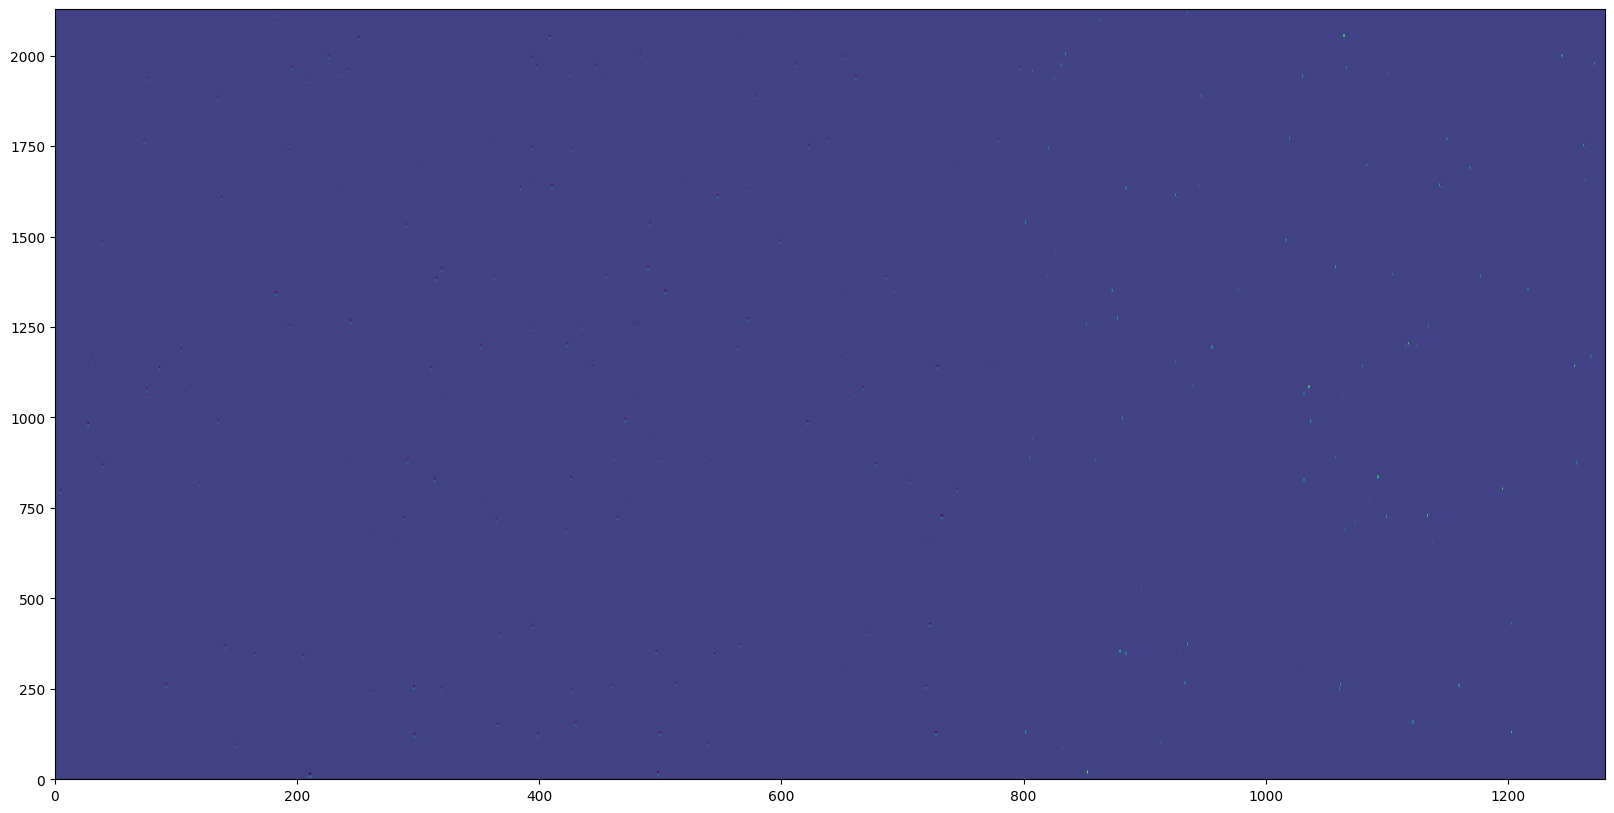

In [17]:
Analyzer.Plot2DWaveform(Noise_baseline_sbtr, xedges, yedges)
Analyzer.Plot2DWaveform(Ar39_baseline_sbtr, xedges, yedges)

In [14]:
#Now to process a bunch of events at once:

In [18]:
H, W = 1280, 2128
num_arrays = 1000

Ar39s = np.memmap("/scratch/7DayLifetime/mking/1000_evts_doped/signal.raw", dtype=np.float32, mode='w+', shape=(num_arrays, H, W))

for i in range(int(len(infile.keys())/2)):
    if (i%100 == 0):
        print(i)
    Ar39_key = infile.keys()[2*i+1]
    Ar39s[i]=(infile[Ar39_key].to_numpy()[0])

0
100
200
300
400
500
600
700
800
900


In [19]:
# Assume each numpy array has shape (H, W)
Noises = np.memmap("/scratch/7DayLifetime/mking/1000_evts_doped/noise.raw", dtype=np.float32, mode='w+', shape=(num_arrays, H, W))

for i in range(int(len(infile.keys())/2)):
    if (i%100 == 0):
        print(i)
    Noise_key = infile.keys()[2*i]
    #Baseline subtract the average of that event along each channel, after subtracting out the Ar39 signal
    Noises[i]=(infile[Noise_key].to_numpy()[0])-np.mean(infile[Noise_key].to_numpy()[0]-Ar39s[i],axis=1)[:,np.newaxis]

Noises.flush()
del Noises
del Ar39s

infile.close()
del infile
gc.collect() 


0
100
200
300
400
500
600
700
800
900


27487

In [20]:
#Now that npy files have been created, start here:
import numpy as np
import matplotlib.pyplot as plt
from Analyzer import Analyzer as Analyzer
import gc

In [22]:
# Load the memmap files
noise_memmap = np.memmap("/scratch/7DayLifetime/mking/1000_evts_doped/noise.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))
signal_memmap = np.memmap("/scratch/7DayLifetime/mking/1000_evts_doped/signal.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))

# Define ROI: Mark 1 where signal is nonzero, else 0
ROI = (signal_memmap!=0).astype(np.uint8)
np.save("/scratch/7DayLifetime/mking/1000_evts_doped/roi.npy", ROI.astype(np.uint8))

print(np.all(signal_memmap ==0 ))
print(np.all(ROI==0))

#del noise_memmap, signal_memmap

False
False


In [25]:
ThisGoodEventIndex = EventsWithAr39[0]
ThisAr39 = signal_memmap[ThisGoodEventIndex]
print(np.shape(ThisAr39))
print(np.nonzero(ThisAr39))

ThisROI = ROI[ThisGoodEventIndex]
print(np.nonzero(ThisROI))
print(np.array_equal(np.nonzero(ThisAr39) , np.nonzero(ThisROI)))

(1280, 2128)
(array([   0,    0,    0, ..., 1272, 1272, 1272], shape=(11549,)), array([ 115,  116,  117, ..., 1979, 1980, 1981], shape=(11549,)))
(array([   0,    0,    0, ..., 1272, 1272, 1272], shape=(11549,)), array([ 115,  116,  117, ..., 1979, 1980, 1981], shape=(11549,)))
True


In [57]:
del ROI

In [62]:
ROI = np.memmap("roi.npy", dtype=np.uint8, mode='r', shape=(1000, 1280, 2128))
ROI2 = np.load("roi.npy")

ThisROI = ROI[ThisGoodEventIndex]
print(np.nonzero(ThisROI))

ThisROI2 = ROI2[ThisGoodEventIndex]
print(np.nonzero(ThisROI2))

(array([139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 142, 142,
       142, 142, 142, 142, 142, 142, 142, 142, 142, 142, 142, 142, 142,
       142, 143, 143, 143, 143, 143, 143, 143, 143, 143, 143, 143, 143,
       143, 143, 143, 143, 143, 143, 143, 144, 144, 144, 536, 536, 536,
       537, 537, 537, 537, 537, 537, 537, 537, 537, 537, 537, 537, 537,
       537, 537, 537, 537, 537, 537, 538, 538, 538, 538, 538, 538, 538,
       538, 538, 538, 538, 538, 538, 538, 538, 538, 538, 538, 539, 540,
       540, 541, 541, 541, 541, 541, 541, 541, 541, 541, 541, 541, 541,
       915, 916, 916, 916, 916, 916, 916, 916, 916, 916, 916, 916, 916,
       916, 916, 916, 916, 917, 917, 917, 917, 917, 917, 917, 917, 917,
       917, 917, 917, 917, 917, 917, 917, 918, 918, 921, 921, 921, 921,
       921, 921, 921, 921, 921, 921, 921]), array([1514, 1515, 1516, 1517, 1518, 1521, 1522, 1523, 1524, 1525, 1526,
       1510, 1511, 1512, 1513, 1514, 1515, 1516, 1518, 1519, 1520, 1521,
       1522, 1523

In [24]:
#Now search through our 1000 events of Ar39 and establish which ones contain any signal
#Ar39s = np.memmap("signal.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))

count = 0
EventsWithAr39 = []
for i in range(len(signal_memmap)):
    if np.any(signal_memmap[i]):
        count = count+1
        EventsWithAr39.append(i)

print(count)

1000


In [ ]:
from Analyzer import Analyzer as Analyzer
xedges = np.arange(1281)
yedges = np.arange(2129)
Analyzer.Plot2DWaveform(np.log(ThisAr39), xedges, yedges)

In [ ]:
#Go from here for checks

In [14]:
noise_memmap = np.memmap("noise.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))
signal_memmap = np.memmap("signal.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))
ROI = np.load("roi.npy")

In [26]:
count = 0
EventsWithAr39 = []
for i in range(len(signal_memmap)):
    if np.any(signal_memmap[i]):
        count = count+1
        EventsWithAr39.append(i)

print(count)

1000


In [27]:
#Investigate a single event and plot its signal and noise
ThisGoodEventIndex = EventsWithAr39[0]
ThisAr39 = signal_memmap[ThisGoodEventIndex]
print(np.shape(ThisAr39))
print(np.nonzero(ThisAr39))

ThisROI = ROI[ThisGoodEventIndex]
print(np.nonzero(ThisROI))

(1280, 2128)
(array([   0,    0,    0, ..., 1272, 1272, 1272], shape=(11549,)), array([ 115,  116,  117, ..., 1979, 1980, 1981], shape=(11549,)))
(array([   0,    0,    0, ..., 1272, 1272, 1272], shape=(11549,)), array([ 115,  116,  117, ..., 1979, 1980, 1981], shape=(11549,)))


In [28]:
#grab the rows 
Rows_With_signal= np.unique(np.nonzero(ThisAr39)[0])
print(Rows_With_signal)

[   0    3    4    5    6   25   26   27   28   29   30   38   39   40
   41   42   63   64   72   73   74   75   76   77   78   79   85   86
   87   90   91   92   93  101  102  103  104  105  111  112  113  116
  117  118  119  120  133  134  135  136  137  138  139  140  141  142
  143  149  150  152  153  160  163  164  165  166  173  181  182  183
  184  185  192  193  194  195  196  197  200  203  204  205  206  207
  209  210  211  212  224  225  226  227  229  230  232  233  234  236
  237  240  241  242  243  244  245  249  250  251  256  257  259  260
  261  262  263  264  265  278  279  282  283  286  287  288  289  290
  291  292  295  296  297  298  299  309  310  311  312  313  314  315
  316  318  319  320  321  324  326  327  332  333  350  351  352  353
  359  360  361  362  363  364  365  366  367  368  383  384  385  387
  388  390  391  392  393  394  395  396  397  398  399  407  408  409
  410  411  412  421  422  423  424  425  426  427  428  429  430  431
  434 

In [29]:
#Get the noise for this event and background subtract
ThisNoise = noise_memmap[ThisGoodEventIndex]
#Already baseline subtracted now
#AvgNoise = np.mean(ThisNoise-ThisAr39,axis = 1) #Noise is really Noise + Ar39
#Noise_baseline_sbtr = ThisNoise - AvgNoise[:,np.newaxis]

In [30]:
print(np.all(ROI ==0))

False


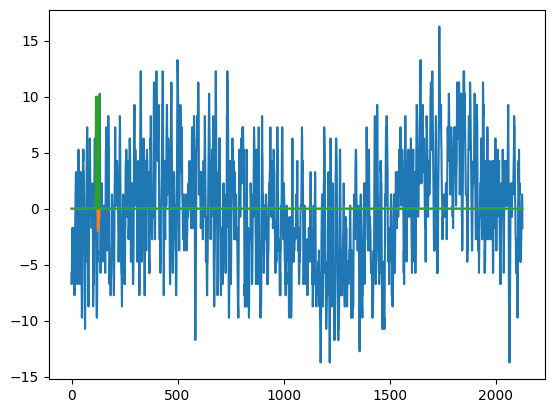

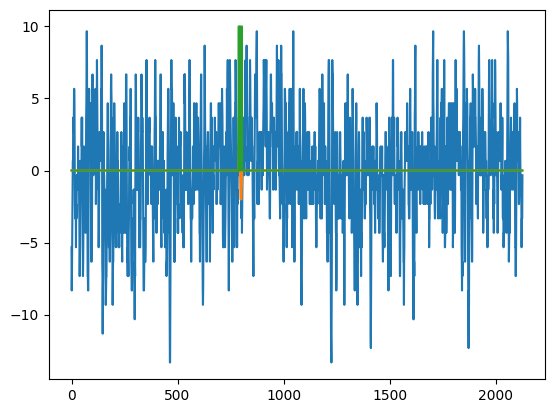

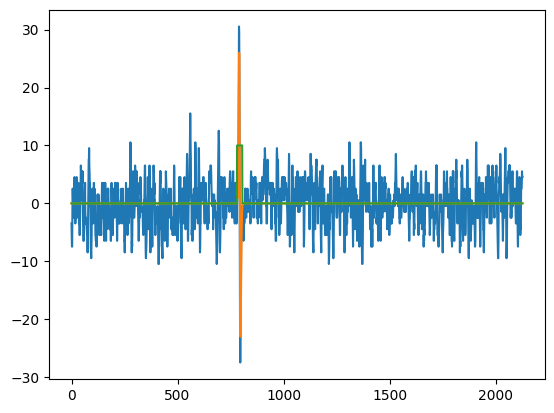

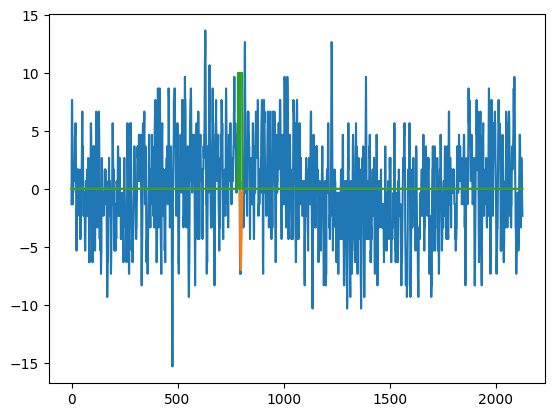

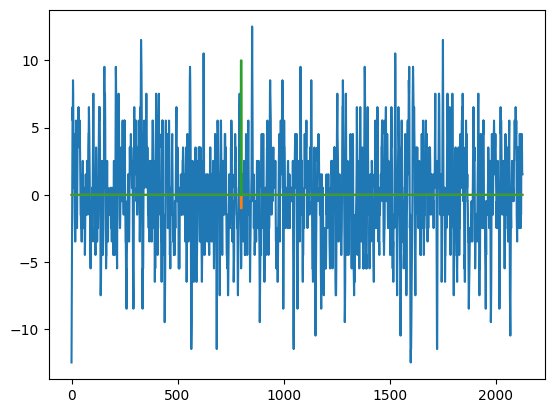

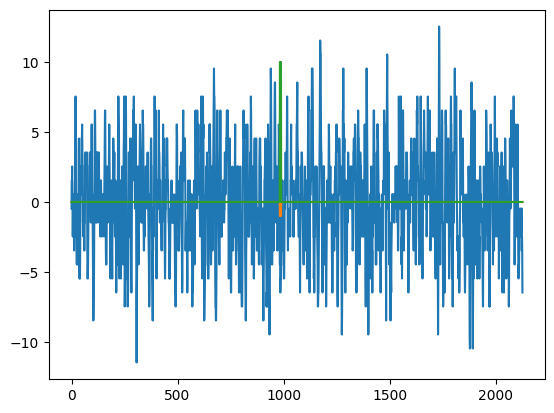

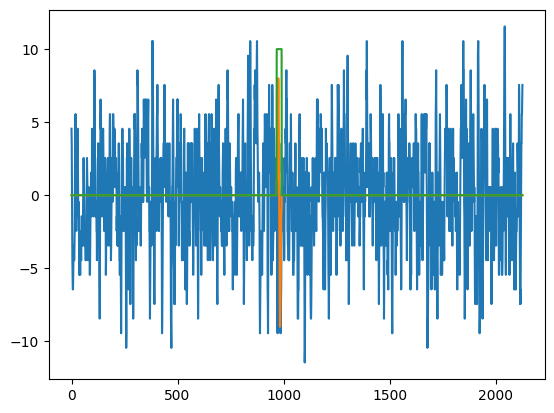

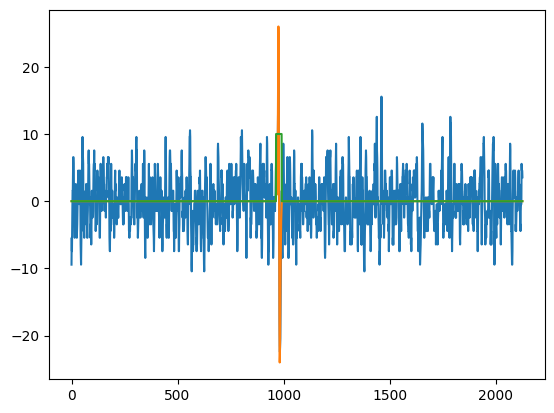

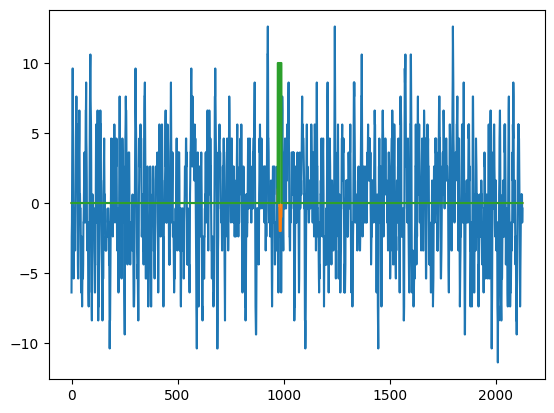

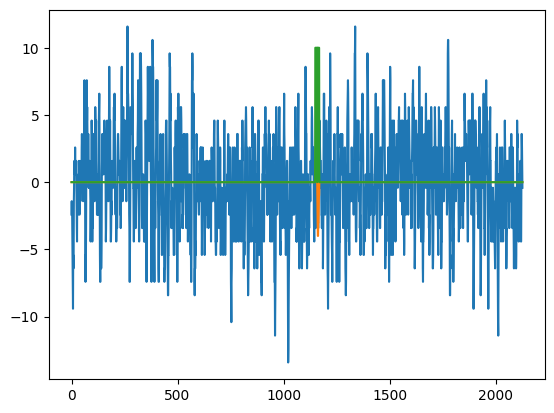

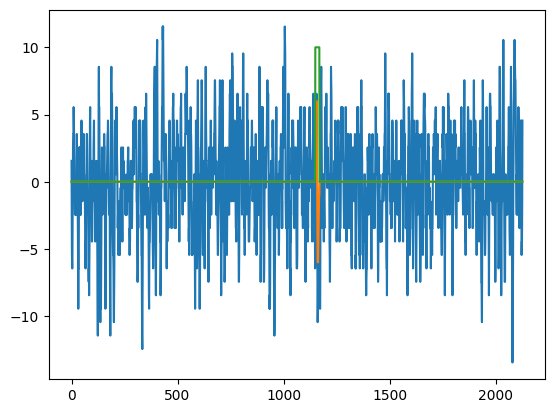

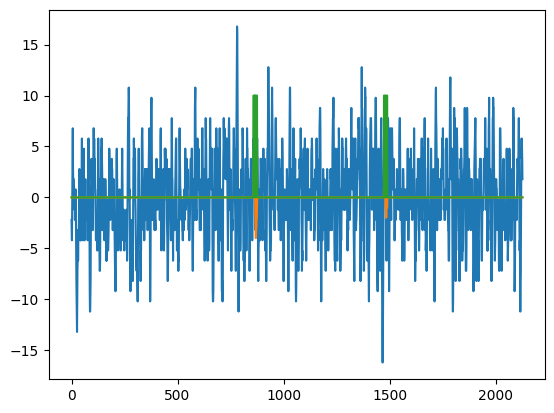

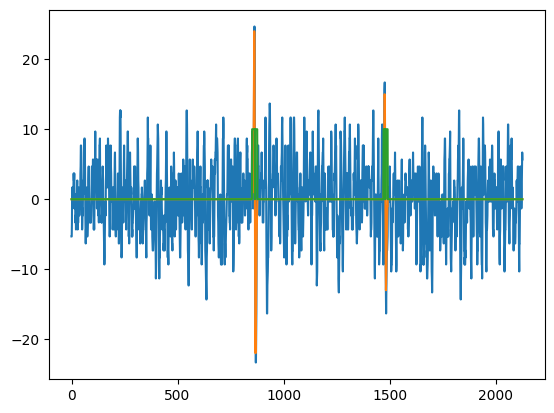

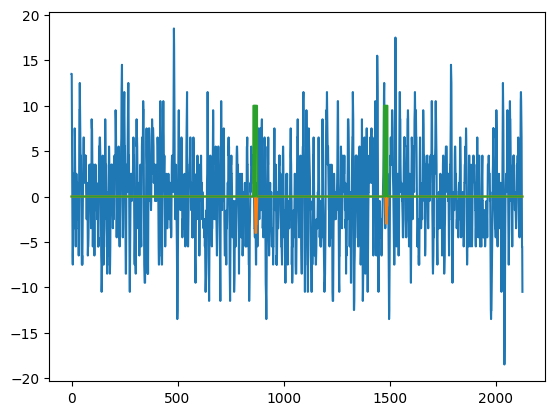

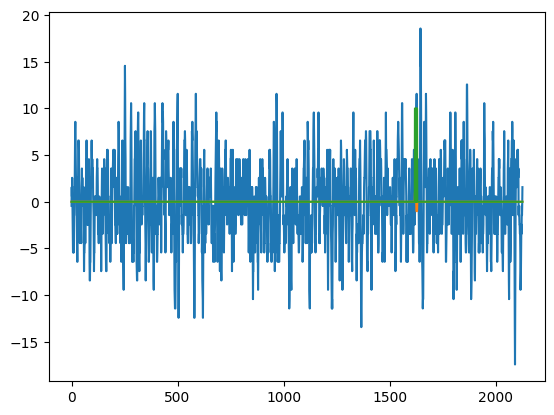

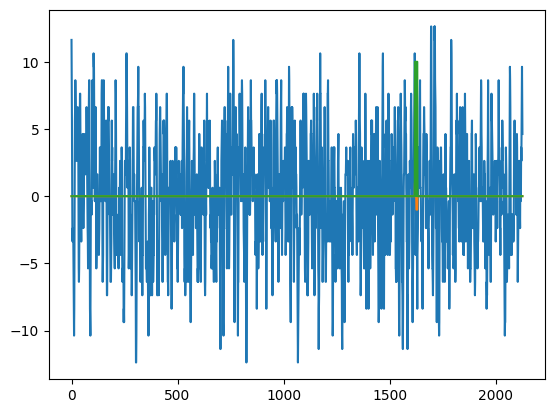

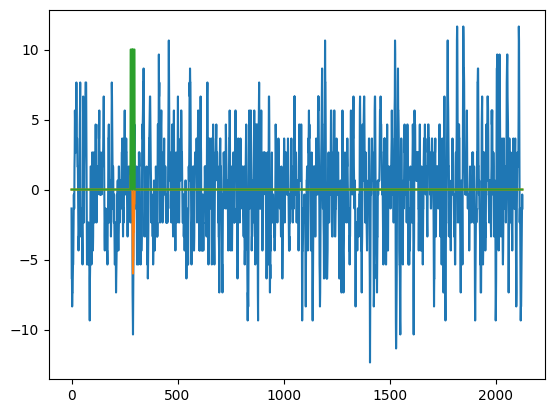

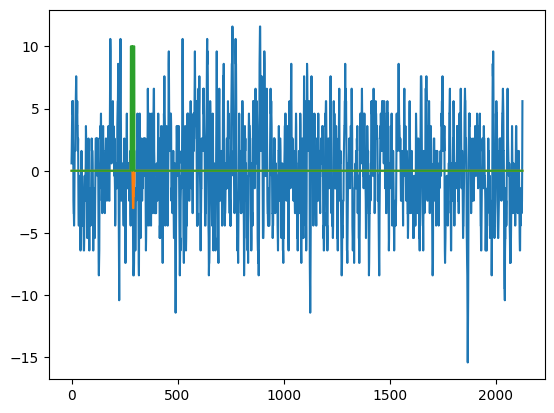

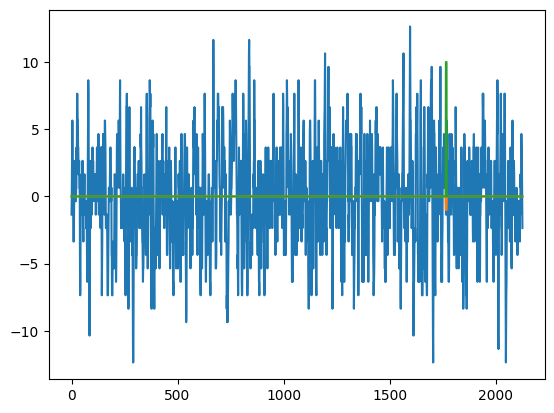

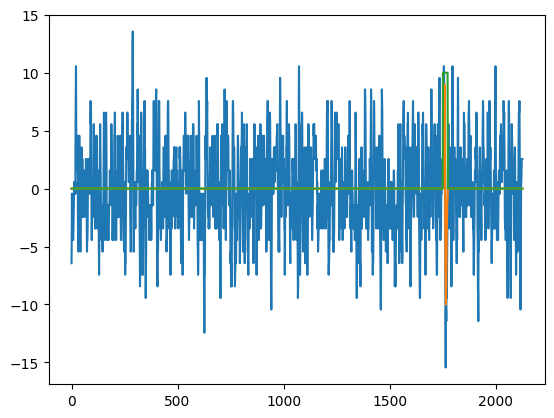

In [33]:
for i in range(20):
    row = Rows_With_signal[i]
    plt.figure()
    #plt.xlim(1300,1400)
    plt.plot(ThisNoise[row]) #checking overlays
    plt.plot(ThisAr39[row])
    plt.plot(ThisROI[row]*10)

In [ ]:
#Not encouraging... Can I make a plot (plane separated) of the maximum ADC values for the Ar-39 on a given channel?
#If it lies below the noise RMS for each channel, may need time-correlations from the get-go.
#Maybe a better plot is the maximum ADC on each plane, since the blips may span a couple of wires
#Multiplane matching could certainly help

In [ ]:
#For each of the EventsWithAr39, sort into the 6 planes. Store maximum ADC value for each event for each plane
# Geometry:
# SortedArray[0][0][0:200] = MegaArray[0:200]     #TPC 0 Plane u
#        SortedArray[1][0][0:200] = MegaArray[200:400]   #TPC 1 Plane u
#        SortedArray[0][1][0:200] = MegaArray[400:600]   #TPC 0 Plane v
#        SortedArray[1][1][0:200] = MegaArray[600:800]   #TPC 1 Plane v
#        SortedArray[0][2]        = MegaArray[800:1040]  #TPC 0 Plane z
#        SortedArray[1][2]        = MegaArray[1040:1280] #TPC 1 Plane z

#Make a 2D array...

#Start with Z plane
#use integral instead of max
# max to compare with noise

#Fill below with 3-tuples corresponding to MaxADC value for (u,v,z)
MaxADCAr39TPC0 = []
MaxADCAr39TPC1 = []

for iEvent in EventsWithAr39:
    ThisAr39 = Ar39s[iEvent]
    #First decide which TPC the ar-39 is in, then take the maximum ADC value across each plane
    
    

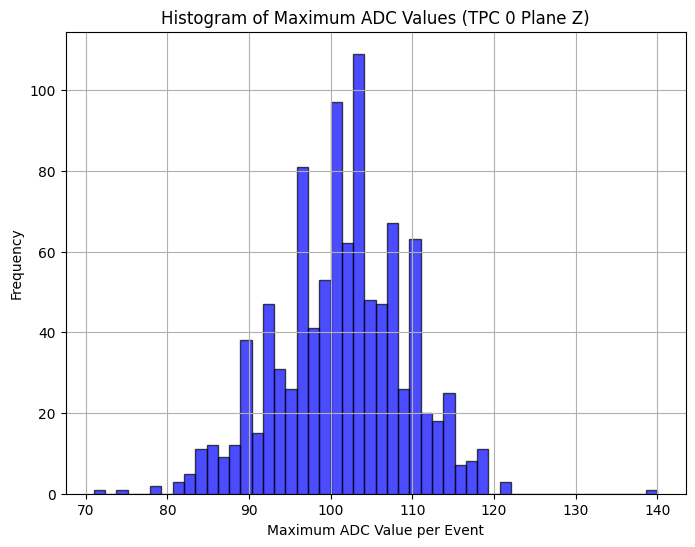

347
172


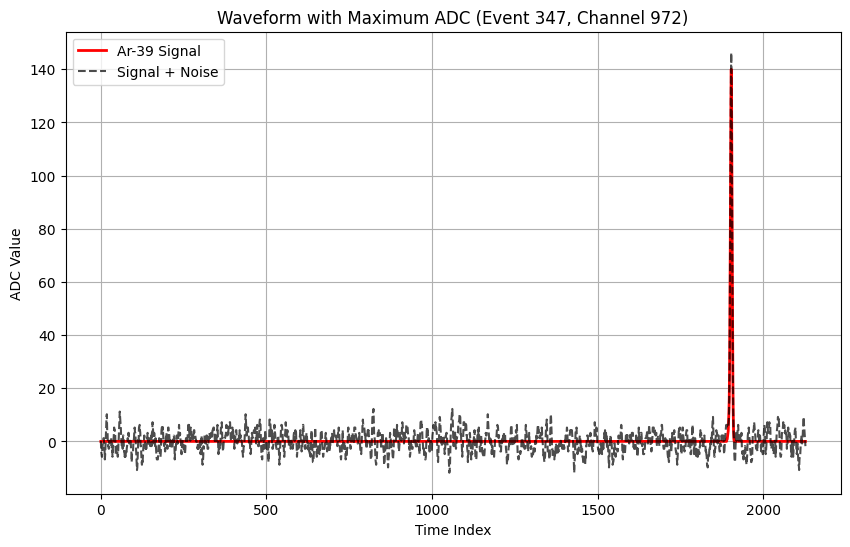

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Load memmap files
noise_memmap = np.memmap("/scratch/7DayLifetime/mking/1000_evts_doped/noise.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))
signal_memmap = np.memmap("/scratch/7DayLifetime/mking/1000_evts_doped/signal.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))
ROI = np.load("/scratch/7DayLifetime/mking/1000_evts_doped/roi.npy")

# Extract TPC 0 Plane Z (channels 800-1039)
signal_data = signal_memmap[:, 800:1040, :]
noise_data = noise_memmap[:, 800:1040, :]
ROI_data = ROI[:,800:1040, :]

# Find the maximum ADC of any waveform in each event
## Change this for the doped sample - want maximum ADC value per blip -- need some algorithm to sort blip regions
## Something like definining a blip region as contiguous, defining it by its center, radius, peak height.
max_adc_per_event = np.max(signal_data, axis=(1, 2))  # Max ADC per event

# Filter out events where max ADC is 0
nonzero_max_adc = max_adc_per_event[max_adc_per_event > 0]

# Plot histogram of maximum ADC values
plt.figure(figsize=(8, 6))
plt.hist(nonzero_max_adc, bins=50, alpha=0.7, color='b', edgecolor='black')
plt.xlabel("Maximum ADC Value per Event")
plt.ylabel("Frequency")
plt.title("Histogram of Maximum ADC Values (TPC 0 Plane Z)")
plt.grid(True)
plt.show()

# Find the event and channel with the global maximum ADC
event_idx, channel_idx, _ = np.unravel_index(np.argmax(signal_data), signal_data.shape)

# Extract the corresponding signal and noise waveforms
signal_waveform = signal_data[event_idx, channel_idx, :]
noise_waveform = noise_data[event_idx, channel_idx, :]

print(event_idx)
print(channel_idx)
# Plot signal overlaid on noise
plt.figure(figsize=(10, 6))
plt.plot(signal_waveform, label="Ar-39 Signal", color='r', linewidth=2)
plt.plot(noise_waveform, label="Signal + Noise", color='k', linestyle='dashed', alpha=0.7)
#plt.plot(ROI_data[event_idx,channel_idx,:]*100, label="ROI", color='g')
plt.xlabel("Time Index")
plt.ylabel("ADC Value")
plt.title(f"Waveform with Maximum ADC (Event {event_idx}, Channel {channel_idx + 800})")
plt.legend()
plt.grid(True)
plt.show()

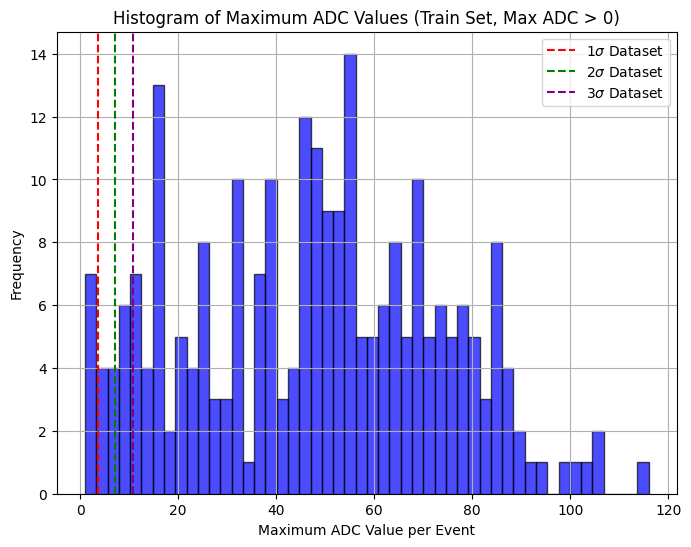

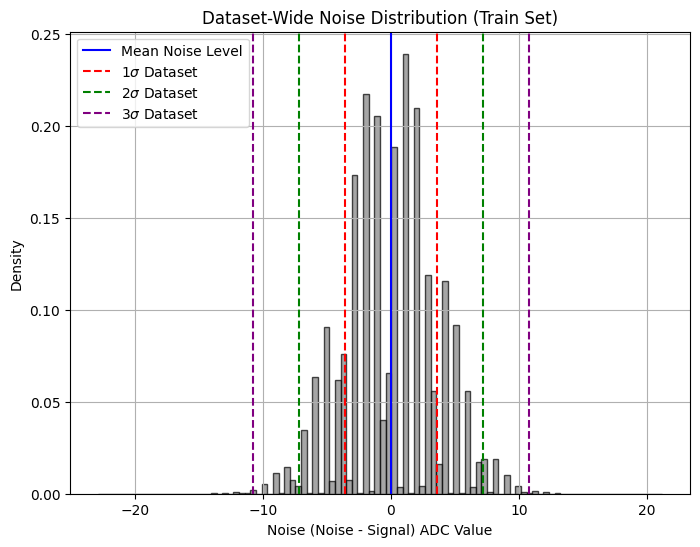

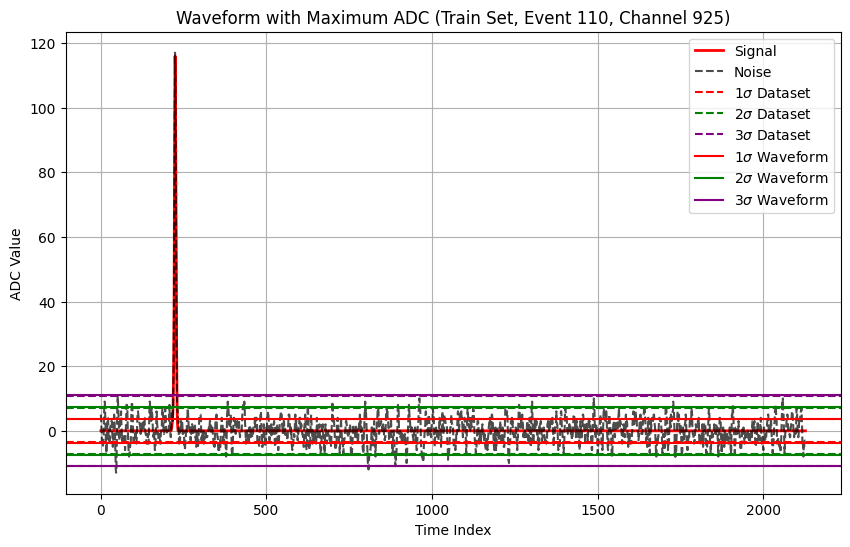

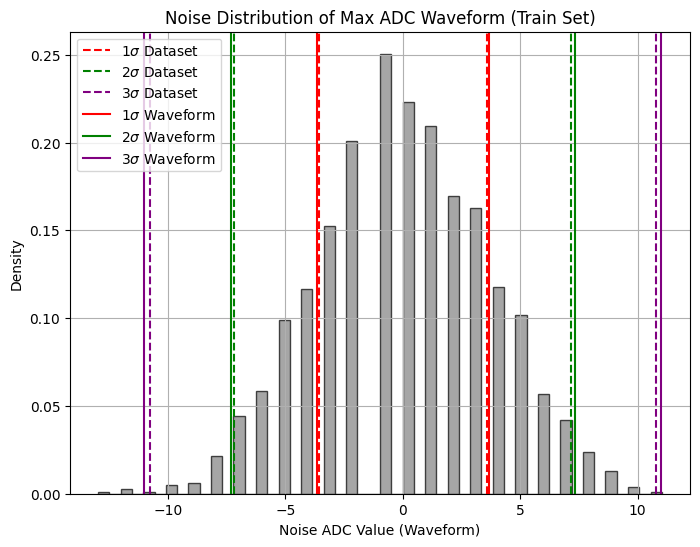

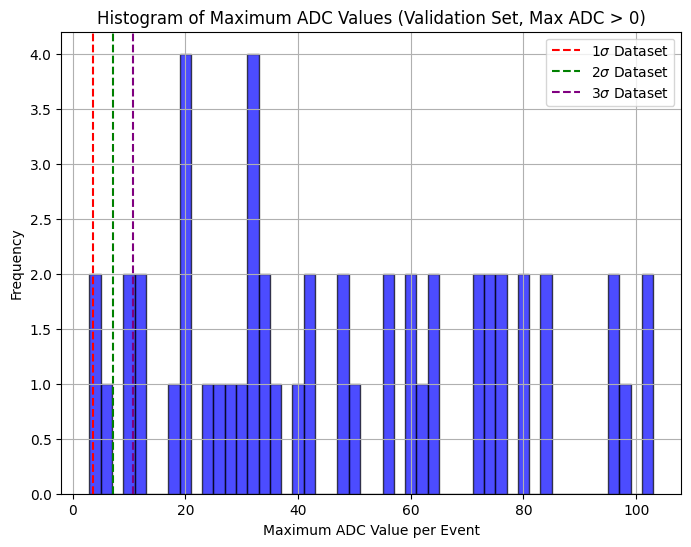

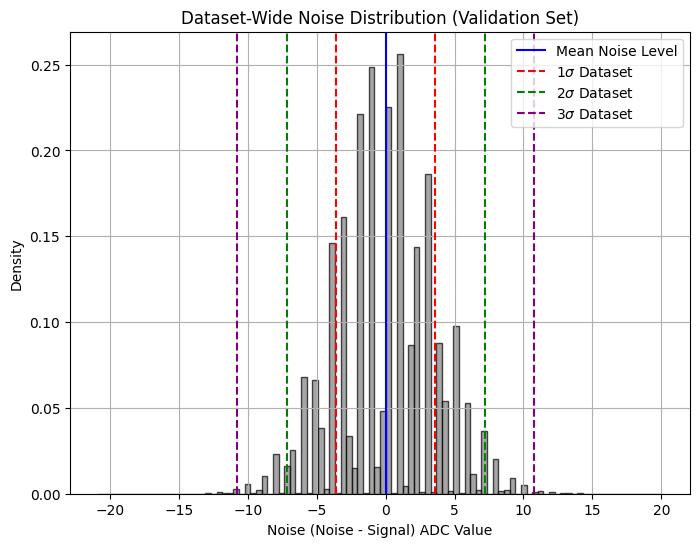

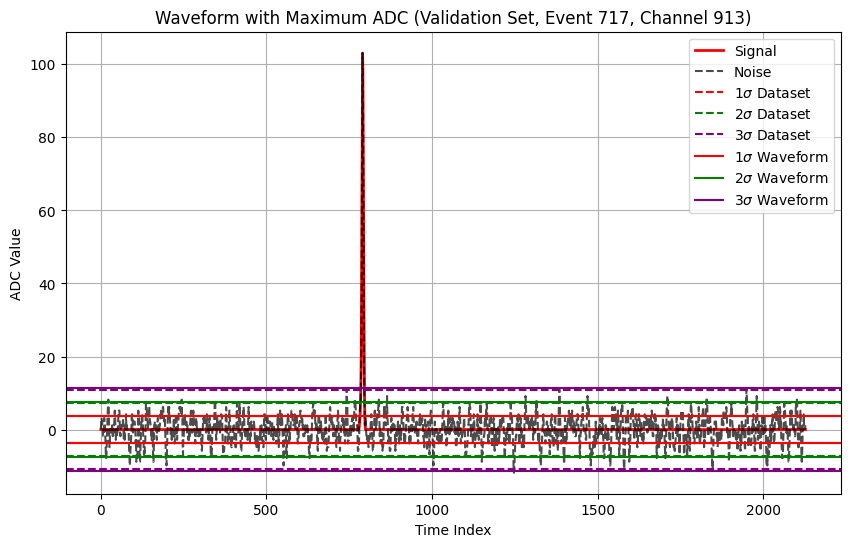

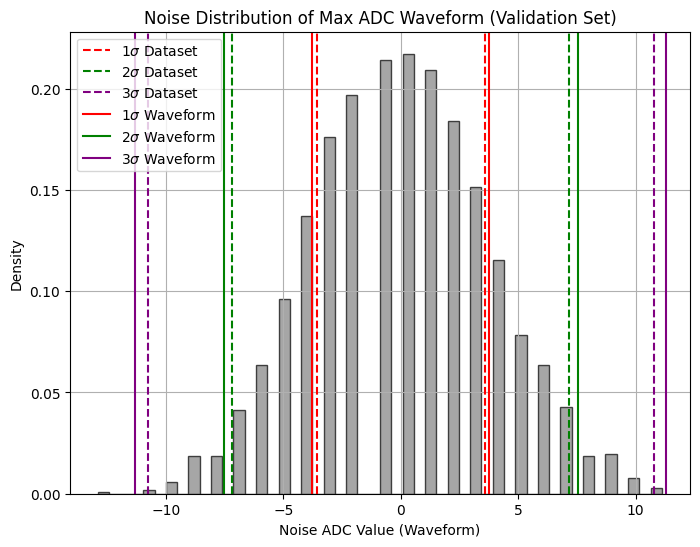

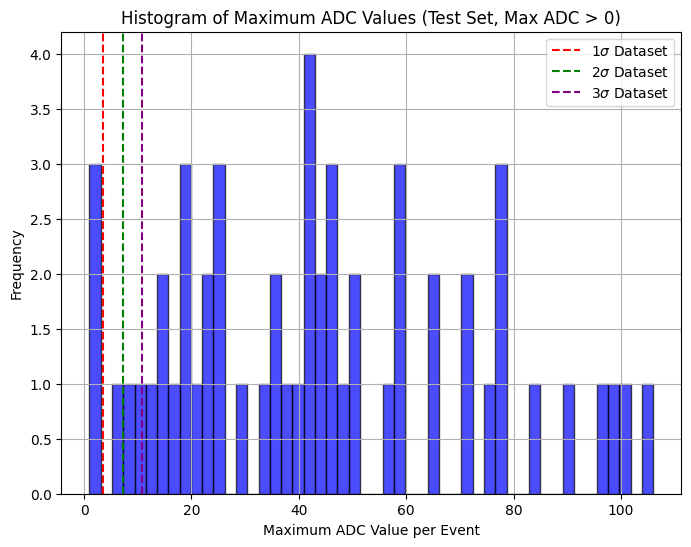

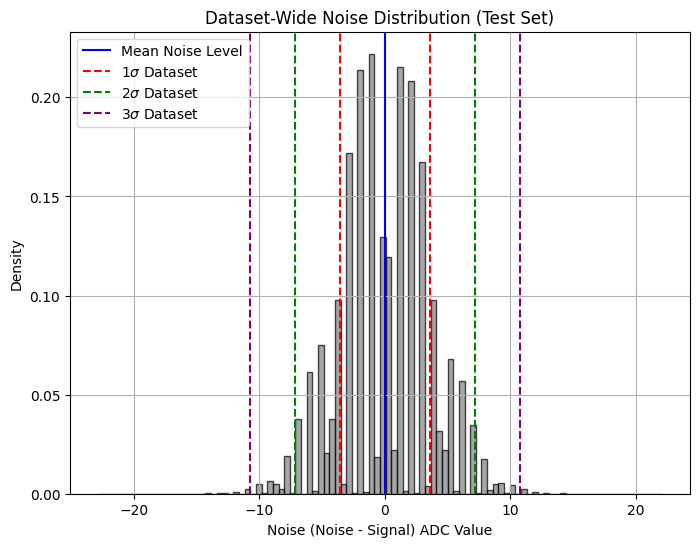

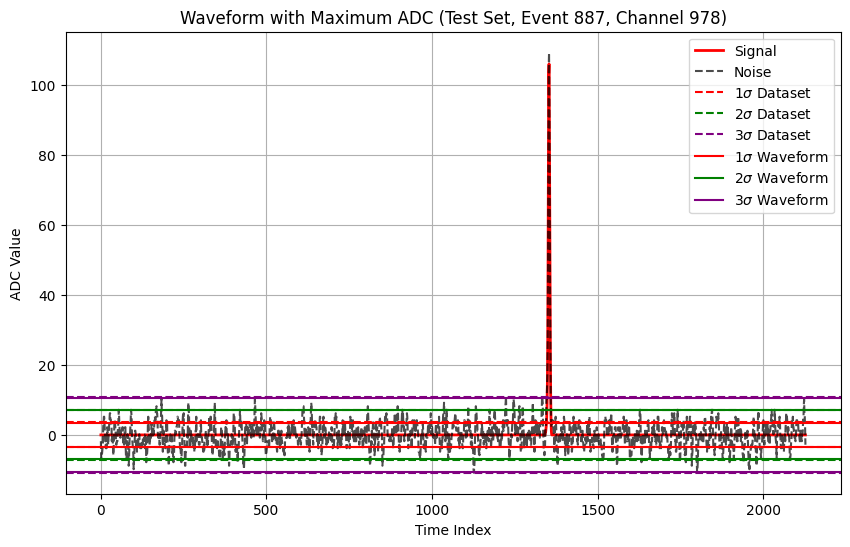

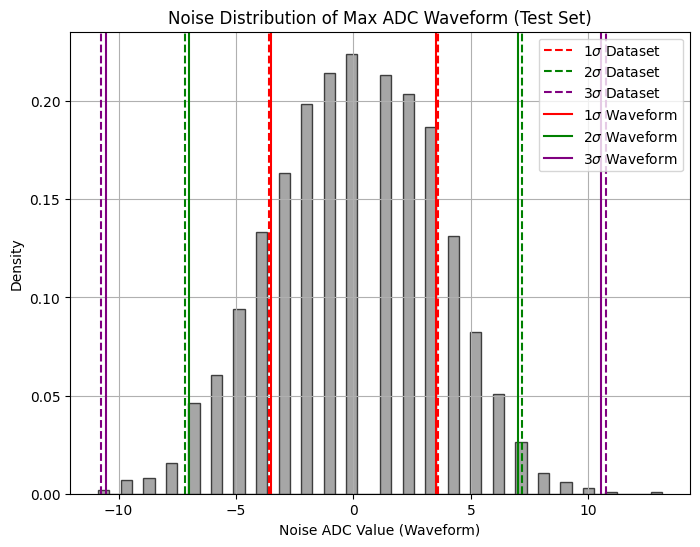

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Load memmap files
noise_memmap = np.memmap("noise.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))
signal_memmap = np.memmap("signal.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))

# Extract TPC 0 Plane Z (channels 800-1039)
signal_data = signal_memmap[:, 800:1040, :]
noise_data = noise_memmap[:, 800:1040, :]

# Compute noise distribution (Noise - Signal)
noise_distribution = noise_data - signal_data  # This is the actual noise

# Split into train (70%), validation (15%), test (15%)
num_events = signal_data.shape[0]
train_size = int(0.7 * num_events)
val_size = int(0.15 * num_events)
test_size = num_events - train_size - val_size

train_indices = np.arange(train_size)
val_indices = np.arange(train_size, train_size + val_size)
test_indices = np.arange(train_size + val_size, num_events)

splits = {
    "Train": train_indices,
    "Validation": val_indices,
    "Test": test_indices
}

# Function to plot visualizations
def plot_visualizations(name, indices):
    # Extract data for the current split
    signal_subset = signal_data[indices]
    noise_subset = noise_data[indices]
    noise_dist_subset = noise_distribution[indices]

    # Compute max ADC per event
    max_adc_per_event = np.max(signal_subset, axis=(1, 2))  # Max ADC per event
    nonzero_max_adc = max_adc_per_event[max_adc_per_event > 0]  # Filter max ADC > 0

    # Compute dataset-wide noise statistics
    noise_values = noise_dist_subset.flatten()
    noise_mean = np.mean(noise_values)
    noise_std = np.std(noise_values)

    # Histogram of max ADC values
    plt.figure(figsize=(8, 6))
    plt.hist(nonzero_max_adc, bins=50, alpha=0.7, color='b', edgecolor='black')
    plt.axvline(noise_mean + noise_std, color='r', linestyle='dashed', label=r'$1\sigma$ Dataset')
    plt.axvline(noise_mean + 2 * noise_std, color='g', linestyle='dashed', label=r'$2\sigma$ Dataset')
    plt.axvline(noise_mean + 3 * noise_std, color='purple', linestyle='dashed', label=r'$3\sigma$ Dataset')
    plt.xlabel("Maximum ADC Value per Event")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Maximum ADC Values ({name} Set, Max ADC > 0)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Dataset-wide noise distribution histogram
    plt.figure(figsize=(8, 6))
    plt.hist(noise_values, bins=100, alpha=0.7, color='gray', edgecolor='black', density=True)
    plt.axvline(noise_mean, color='blue', linestyle='solid', label="Mean Noise Level")
    plt.axvline(noise_mean + noise_std, color='r', linestyle='dashed', label=r'$1\sigma$ Dataset')
    plt.axvline(noise_mean - noise_std, color='r', linestyle='dashed')
    plt.axvline(noise_mean + 2 * noise_std, color='g', linestyle='dashed', label=r'$2\sigma$ Dataset')
    plt.axvline(noise_mean - 2 * noise_std, color='g', linestyle='dashed')
    plt.axvline(noise_mean + 3 * noise_std, color='purple', linestyle='dashed', label=r'$3\sigma$ Dataset')
    plt.axvline(noise_mean - 3 * noise_std, color='purple', linestyle='dashed')
    plt.xlabel("Noise (Noise - Signal) ADC Value")
    plt.ylabel("Density")
    plt.title(f"Dataset-Wide Noise Distribution ({name} Set)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Find the event and channel with the global max ADC
    event_idx, channel_idx, _ = np.unravel_index(np.argmax(signal_subset), signal_subset.shape)

    # Extract the corresponding signal and noise waveforms
    signal_waveform = signal_subset[event_idx, channel_idx, :]
    noise_waveform = noise_subset[event_idx, channel_idx, :]
    noise_waveform_distribution = noise_distribution[event_idx, channel_idx, :]

    # Compute waveform-specific noise statistics
    waveform_noise_mean = np.mean(noise_waveform_distribution)
    waveform_noise_std = np.std(noise_waveform_distribution)

    # Plot signal overlaid on noise
    plt.figure(figsize=(10, 6))
    plt.plot(signal_waveform, label="Signal", color='r', linewidth=2)
    plt.plot(noise_waveform, label="Noise", color='k', linestyle='dashed', alpha=0.7)
    plt.axhline(noise_mean + noise_std, color='r', linestyle='dashed', label=r'$1\sigma$ Dataset')
    plt.axhline(noise_mean - noise_std, color='r', linestyle='dashed')
    plt.axhline(noise_mean + 2 * noise_std, color='g', linestyle='dashed', label=r'$2\sigma$ Dataset')
    plt.axhline(noise_mean - 2 * noise_std, color='g', linestyle='dashed')
    plt.axhline(noise_mean + 3 * noise_std, color='purple', linestyle='dashed', label=r'$3\sigma$ Dataset')
    plt.axhline(noise_mean - 3 * noise_std, color='purple', linestyle='dashed')
    plt.axhline(waveform_noise_mean + waveform_noise_std, color='r', linestyle='solid', label=r'$1\sigma$ Waveform')
    plt.axhline(waveform_noise_mean - waveform_noise_std, color='r', linestyle='solid')
    plt.axhline(waveform_noise_mean + 2 * waveform_noise_std, color='g', linestyle='solid', label=r'$2\sigma$ Waveform')
    plt.axhline(waveform_noise_mean - 2 * waveform_noise_std, color='g', linestyle='solid')
    plt.axhline(waveform_noise_mean + 3 * waveform_noise_std, color='purple', linestyle='solid', label=r'$3\sigma$ Waveform')
    plt.axhline(waveform_noise_mean - 3 * waveform_noise_std, color='purple', linestyle='solid')
    plt.xlabel("Time Index")
    plt.ylabel("ADC Value")
    plt.title(f"Waveform with Maximum ADC ({name} Set, Event {indices[event_idx]}, Channel {channel_idx + 800})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Histogram of noise for max ADC waveform
    plt.figure(figsize=(8, 6))
    plt.hist(noise_waveform_distribution, bins=50, alpha=0.7, color='gray', edgecolor='black', density=True)
    plt.axvline(noise_mean + noise_std, color='r', linestyle='dashed', label=r'$1\sigma$ Dataset')
    plt.axvline(noise_mean - noise_std, color='r', linestyle='dashed')
    plt.axvline(noise_mean + 2 * noise_std, color='g', linestyle='dashed', label=r'$2\sigma$ Dataset')
    plt.axvline(noise_mean - 2 * noise_std, color='g', linestyle='dashed')
    plt.axvline(noise_mean + 3 * noise_std, color='purple', linestyle='dashed', label=r'$3\sigma$ Dataset')
    plt.axvline(noise_mean - 3 * noise_std, color='purple', linestyle='dashed')
    plt.axvline(waveform_noise_mean + waveform_noise_std, color='r', linestyle='solid', label=r'$1\sigma$ Waveform')
    plt.axvline(waveform_noise_mean - waveform_noise_std, color='r', linestyle='solid')
    plt.axvline(waveform_noise_mean + 2 * waveform_noise_std, color='g', linestyle='solid', label=r'$2\sigma$ Waveform')
    plt.axvline(waveform_noise_mean - 2 * waveform_noise_std, color='g', linestyle='solid')
    plt.axvline(waveform_noise_mean + 3 * waveform_noise_std, color='purple', linestyle='solid', label=r'$3\sigma$ Waveform')
    plt.axvline(waveform_noise_mean - 3 * waveform_noise_std, color='purple', linestyle='solid')
    plt.xlabel("Noise ADC Value (Waveform)")
    plt.ylabel("Density")
    plt.title(f"Noise Distribution of Max ADC Waveform ({name} Set)")
    plt.legend()
    plt.grid(True)
    plt.show()

# Generate visualizations for each dataset split
for split_name, split_indices in splits.items():
    plot_visualizations(split_name, split_indices)

In [ ]:
#Benchmark NN against threshold cut of 3,4,5 noise sigma above 0.
#Make a selection notebook that does this
#Make it even fancier by creating an ROI by finding peak at X sigma then tracing down 
#left and right continuously until below 2 sigma or something.

In [ ]:
#Thinking about how I want to set up my training data...
#I could literally do Ar39 + Noise, Noise. No shifting around yet. My worry is that the wire slices
#Which go through the side of the blip are going to be useless. Not my problem yet??

#I can also make an array to keep track of which channels have Ar39 or not

#I should also baseline subtract all the noise before overlaying


Rows_With_Signal = []
for Ar39EventIndex in EventsWithAr39:
    ThisAr39 = Ar39s[Ar39EventIndex]
    Rows_With_Signal.append(np.unique(np.nonzero(ThisAr39)[0]))

#So ROI label of 1 iff for Overlays[iEvent][iChannel], iChannel is in Rows_With_Signal[iEvent]
# ROI label of 0 otherwise, which means no Ar39 in waveform
# Waveforms are length 2128. Maybe consider slicing smaller later?

#ROI_Matrix has shape (nEvents, nChannels)
ROI_Matrix = 

In [ ]:
# Now set up a CNN

In [ ]:
#Keep Ar39 to Noise proportion like what we'd expect
#Then if it doesn't perform well, give it an augmented dataset

In [ ]:
#Memory management ideas:
### Only keep Ar39 rows which 

In [ ]:
# Next steps:
# Store ROI as per event: which channel and which time range
# Set up NN
# See what initial training looks like
# Don't futz around with memory yet or worry too much about dataset/size
#ROI is 1 iff sig \neq 0 for each timetick
# Model will pick up signal / noise overlap


In [ ]:
print(np.shape(Ar39s))

In [ ]:
#Start running from here again

In [ ]:
# Baseline subtract the entire noise array

AvgNoises = np.mean(Noises,axis = 2)
Noises_baseline_subtr = Noises - AvgNoises[:,:,np.newaxis]
del Noises
del AvgNoises

Overlays = Noises_baseline_subtr + Ar39s
del Noises_baseline_subtr

In [ ]:
#Try doing it with memory map
noise_memmap = np.memmap("noise.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))
signal_memmap = np.memmap("signal.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))

In [ ]:
print(np.shape(Overlays))

In [ ]:
ROI = (Ar39s != 0).astype(int)

In [ ]:
#Normalize waveforms to stabilize training -- mean should already be 0, but this is good practice
def normalize_waveforms(waveforms):
    mean = np.mean(waveforms, axis=(1, 2), keepdims=True)  # Mean per waveform
    std = np.std(waveforms, axis=(1, 2), keepdims=True) + 1e-6  # Avoid division by zero
    return (waveforms - mean) / std

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import os
from sklearn.metrics import precision_recall_curve, confusion_matrix, f1_score, precision_score, recall_score

In [2]:
# Load memmap files
signal_memmap = np.memmap("/scratch/7DayLifetime/mking/1000_evts_standard/signal.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))
noise_memmap = np.memmap("/scratch/7DayLifetime/mking/1000_evts_standard/noise.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))
roi_memmap = np.load("/scratch/7DayLifetime/mking/1000_evts_standard/roi.npy")  # ROI is loaded directly

# Extract only TPC 0 Plane Z (channels 800-1039)
signal_data = signal_memmap[:, 800:1040, :]
noise_data = noise_memmap[:, 800:1040, :]
roi_data = roi_memmap[:, 800:1040, :]

# Normalize input (optional, based on data distribution)
signal_data = (signal_data - np.mean(signal_data)) / np.std(signal_data)
noise_data = (noise_data - np.mean(noise_data)) / np.std(noise_data)

# Reshape data to treat each channel separately
# X: Input (Noise+Signal), Y: Output (ROI mask)
noise_full = noise_data[:, np.newaxis, :, :]  # Shape: (1000, 1, 240, 2128) -- note (1000 events, 1 image channel i.e. gray, 240 channels, 2128 time ticks)
roi_full = roi_data[:, np.newaxis, :, :]    # Shape: (1000, 1, 240, 2128)

#Below, we reshape our data into 

# Take only the first 2120 elements (212 * 10), then reshape the last dimension into chunks of 212
noise_chunked = noise_full[:, :, :, :2120].reshape(1000, 1, 240, 10, 212)
roi_chunked = roi_full[:, :, :, :2120].reshape(1000, 1, 240, 10, 212)

# Now, we need to reorder the 10 chunks from the 4th dimension to create the final result
X = noise_chunked.swapaxes(1, 3).reshape(10000, 1, 240, 212)
Y = roi_chunked.swapaxes(1, 3).reshape(10000, 1, 240, 212)

In [6]:
#Verify that it worked correctly:
Good = True

for n in range(1000):
    for k in range(212):
        for i in range(10):
            if not np.all(X[10*n + i,:,:,k] == noise_full[n,:,:,212*i+k]):
                Good = False

print(Good)

True
